In [40]:
# Install required library
!pip install xgboost

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.preprocessing import LabelEncoder
import pickle
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Loading the data

In [42]:
df = pd.read_csv('loan_data.csv')

# Showing first rows
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


# Data Overview

In [43]:
print("Dataset Shape:", df.shape)

print("\nData Info:")
df.info()

Dataset Shape: (45000, 14)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64 

In [44]:
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [45]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


# EDA and Visualisation

## Loan Status Distribution

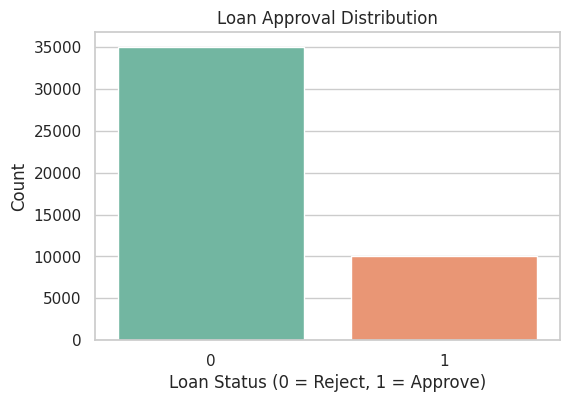

In [46]:
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df, palette='Set2')
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status (0 = Reject, 1 = Approve)")
plt.ylabel("Count")
plt.show()

## Gender vs Loan Status

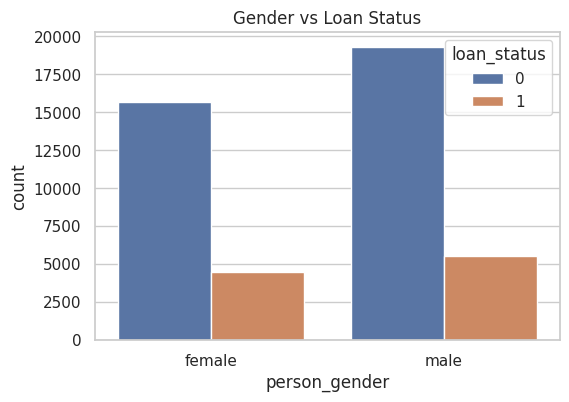

In [47]:
plt.figure(figsize=(6,4))
sns.countplot(x='person_gender', hue='loan_status', data=df)
plt.title("Gender vs Loan Status")
plt.show()

## Credit Score vs Loan Status

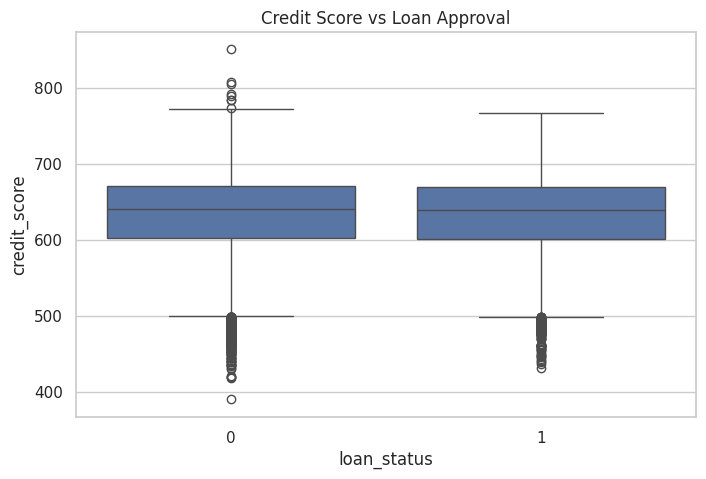

In [48]:
plt.figure(figsize=(8,5))
sns.boxplot(x='loan_status', y='credit_score', data=df)
plt.title("Credit Score vs Loan Approval")
plt.show()

## Loan Amount vs Income

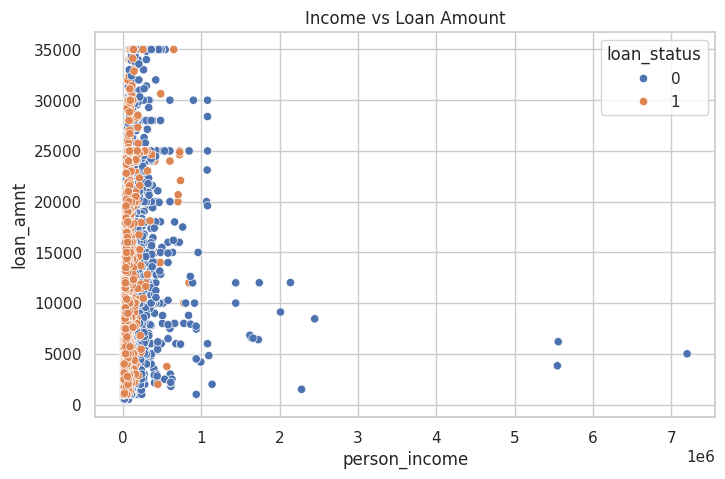

In [49]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='person_income', y='loan_amnt', hue='loan_status', data=df)
plt.title("Income vs Loan Amount")
plt.show()

## Loan Intent Distribution

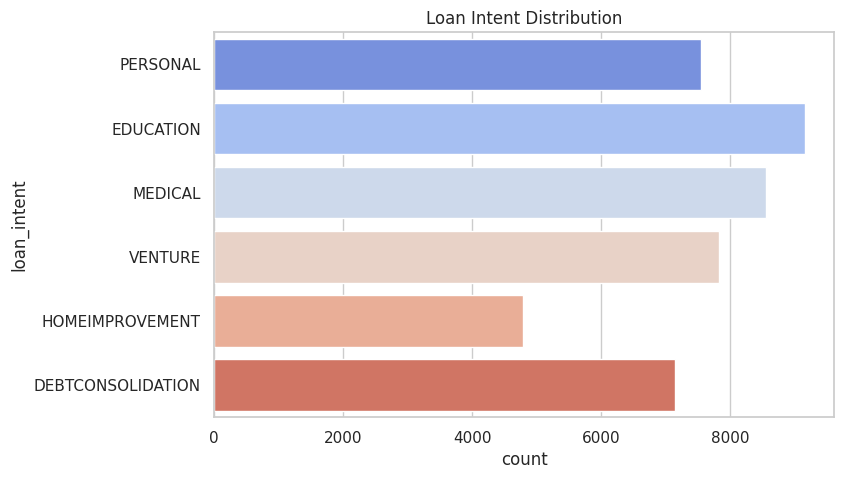

In [50]:
plt.figure(figsize=(8,5))
sns.countplot(y='loan_intent', data=df, palette='coolwarm')
plt.title("Loan Intent Distribution")
plt.show()

# Correlation Heatmap

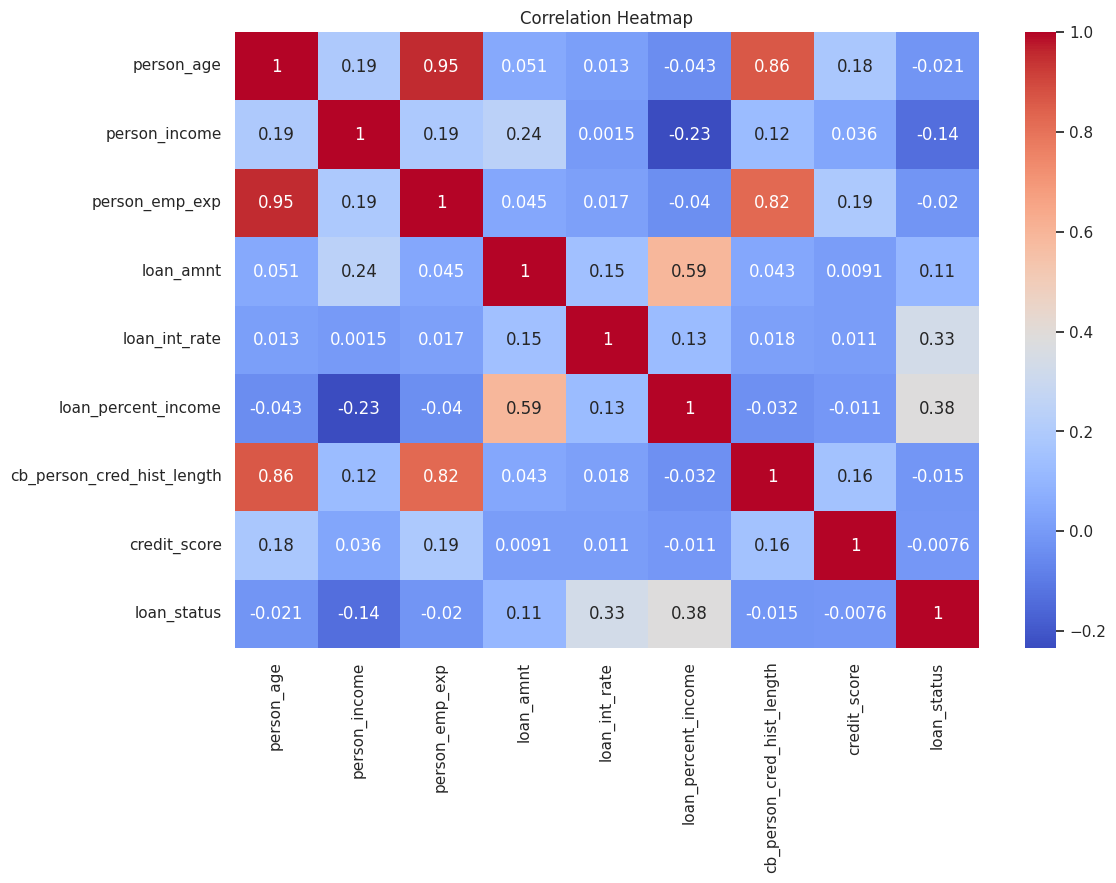

In [51]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Data Preprocessing

### Encoding categorical data

In [52]:
le = LabelEncoder()
encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

pickle.dump(encoders, open('encoders.pkl', 'wb'))

### Feature & Target

In [53]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

### Scaling

In [54]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Spliting

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [56]:
print("=== Target Distribution ===")

print("\nFull Dataset:")
print(y.value_counts(normalize=True))

print("\nTraining Set:")
print(y_train.value_counts(normalize=True))

print("\nTest Set:")
print(y_test.value_counts(normalize=True))

=== Target Distribution ===

Full Dataset:
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64

Training Set:
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64

Test Set:
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64


In [57]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n=== After SMOTE ===")
print(pd.Series(y_train_smote).value_counts())


=== After SMOTE ===
loan_status
0    28000
1    28000
Name: count, dtype: int64


# Train Models

### Logistic Regression

In [58]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train_smote, y_train_smote)

log_predictions = logistic_model.predict(X_test)
log_probabilities = logistic_model.predict_proba(X_test)[:, 1]

## Evaluation


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.97      0.83      0.90      7000
           1       0.61      0.91      0.73      2000

    accuracy                           0.85      9000
   macro avg       0.79      0.87      0.82      9000
weighted avg       0.89      0.85      0.86      9000



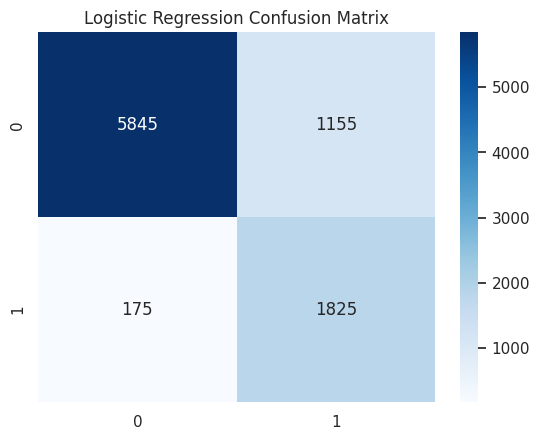

In [59]:
print("\n=== Logistic Regression ===")
print(classification_report(y_test, log_predictions))

cm1 = confusion_matrix(y_test, log_predictions)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

log_auc = roc_auc_score(y_test, log_probabilities)
log_fpr, log_tpr, _ = roc_curve(y_test, log_probabilities)

## Random forest

In [60]:
random_forest = RandomForestClassifier()
random_forest.fit(X_train_smote, y_train_smote)

rf_predictions = random_forest.predict(X_test)
rf_probabilities = random_forest.predict_proba(X_test)[:, 1]

## Evaluation


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      7000
           1       0.80      0.84      0.82      2000

    accuracy                           0.92      9000
   macro avg       0.88      0.89      0.88      9000
weighted avg       0.92      0.92      0.92      9000



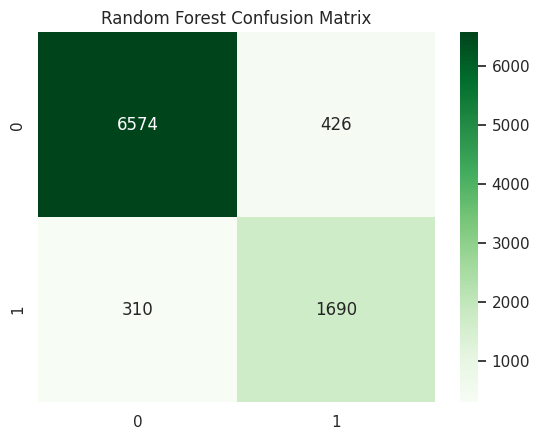

In [61]:
print("\n=== Random Forest ===")
print(classification_report(y_test, rf_predictions))

rf_cm = confusion_matrix(y_test, rf_predictions)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()

rf_auc = roc_auc_score(y_test, rf_probabilities)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probabilities)

## SVM (Support Vector Machine)

In [62]:
svm_model = SVC(probability=True)
svm_model.fit(X_train_smote, y_train_smote)

svm_predictions = svm_model.predict(X_test)
svm_probabilities = svm_model.predict_proba(X_test)[:, 1]

## Evaluation


=== SVM ===
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7000
           1       0.64      0.92      0.75      2000

    accuracy                           0.87      9000
   macro avg       0.80      0.89      0.83      9000
weighted avg       0.90      0.87      0.87      9000



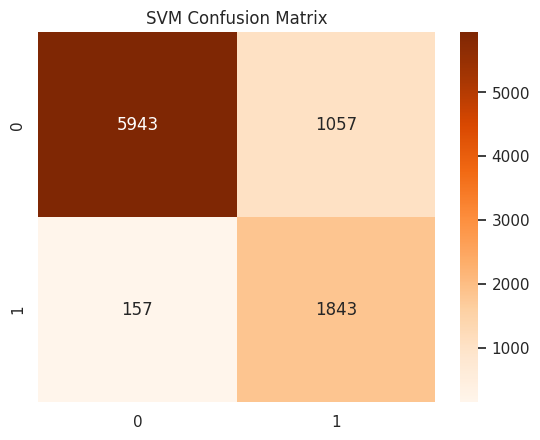

In [63]:
print("\n=== SVM ===")
print(classification_report(y_test, svm_predictions))

svm_cm = confusion_matrix(y_test, svm_predictions)
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Oranges')
plt.title("SVM Confusion Matrix")
plt.show()

svm_auc = roc_auc_score(y_test, svm_probabilities)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probabilities)

## XGBoost

In [64]:
xgboost_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgboost_model.fit(X_train_smote, y_train_smote)

xgb_predictions = xgboost_model.predict(X_test)
xgb_probabilities = xgboost_model.predict_proba(X_test)[:, 1]

## Evaluation


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      7000
           1       0.86      0.83      0.85      2000

    accuracy                           0.93      9000
   macro avg       0.90      0.90      0.90      9000
weighted avg       0.93      0.93      0.93      9000



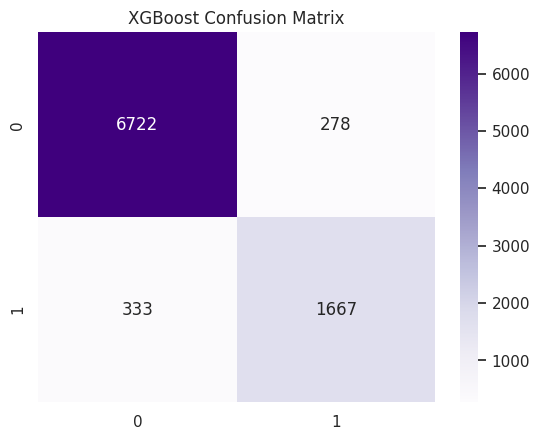

In [65]:
print("\n=== XGBoost ===")
print(classification_report(y_test, xgb_predictions))

xgb_cm = confusion_matrix(y_test, xgb_predictions)
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Purples')
plt.title("XGBoost Confusion Matrix")
plt.show()

xgb_auc = roc_auc_score(y_test, xgb_probabilities)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probabilities)

## ROC Curve comparison

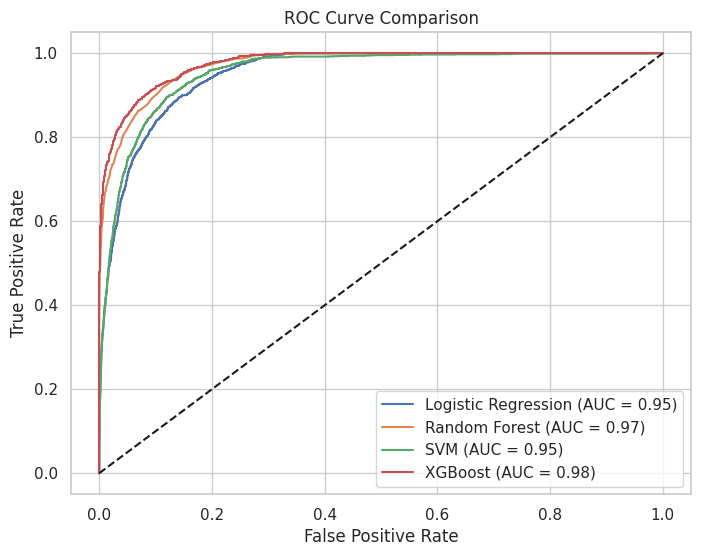

In [66]:
plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr, label=f'Logistic Regression (AUC = {log_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(svm_fpr, svm_tpr, label=f'SVM (AUC = {svm_auc:.2f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.2f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Precision-Recall Curve comparison

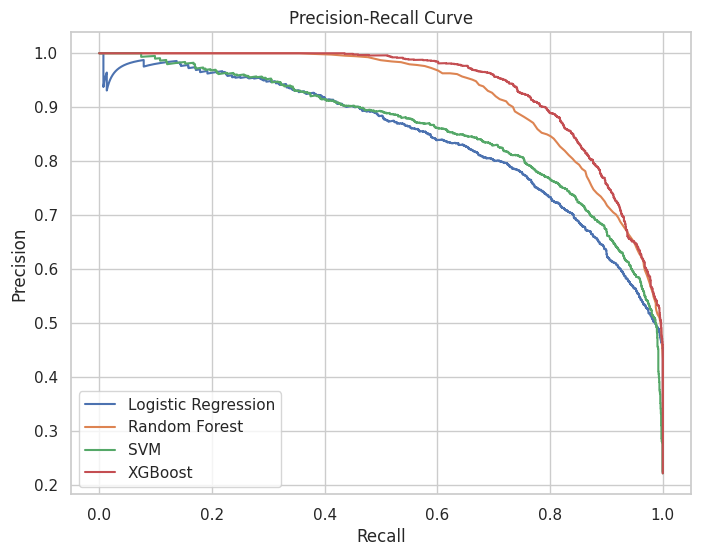

In [67]:
plt.figure(figsize=(8,6))

for probs, name in [
    (log_probabilities, "Logistic Regression"),
    (rf_probabilities, "Random Forest"),
    (svm_probabilities, "SVM"),
    (xgb_probabilities, "XGBoost")
]:
    precision, recall, _ = precision_recall_curve(y_test, probs)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# Model Comparison

## Model auc comparison

                 Model  AUC Score
0  Logistic Regression   0.951420
1        Random Forest   0.972460
2                  SVM   0.954855
3              XGBoost   0.976703


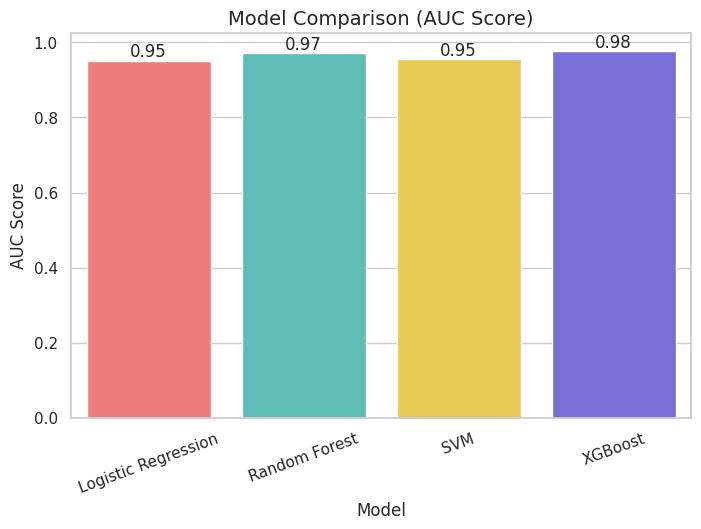

In [68]:
comparison_auc = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM', 'XGBoost'],
    'AUC Score': [log_auc, rf_auc, svm_auc, xgb_auc]
})

print(comparison_auc)

plt.figure(figsize=(8,5))

colors = ['#FF6B6B', '#4ECDC4', '#FFD93D', '#6C5CE7']

sns.barplot(
    x='Model',
    y='AUC Score',
    data=comparison_auc,
    palette=colors
)

plt.title("Model Comparison (AUC Score)", fontsize=14)
plt.xticks(rotation=20)

for index, value in enumerate(comparison_auc['AUC Score']):
    plt.text(index, value + 0.01, f"{value:.2f}", ha='center')

plt.show()

## Model accuracy comparison

                 Model  Accuracy
0  Logistic Regression  0.852222
1        Random Forest  0.918222
2                  SVM  0.865111
3              XGBoost  0.932111


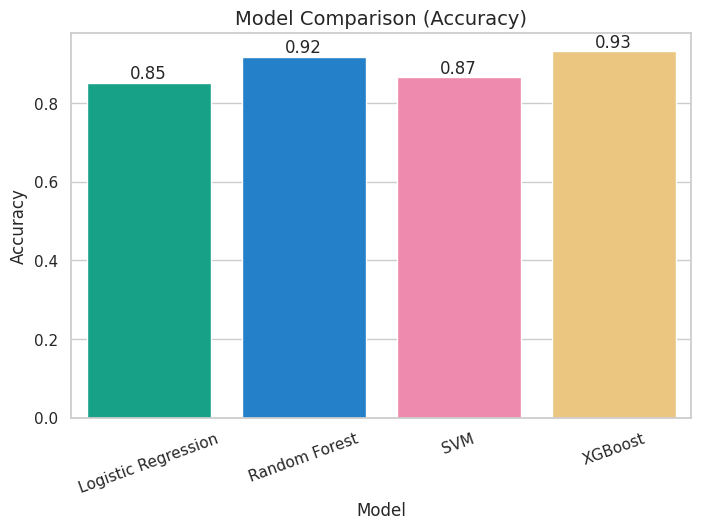

In [69]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, log_predictions)
rf_accuracy = accuracy_score(y_test, rf_predictions)
svm_accuracy = accuracy_score(y_test, svm_predictions)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

comparison_acc = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM', 'XGBoost'],
    'Accuracy': [log_accuracy, rf_accuracy, svm_accuracy, xgb_accuracy]
})

print(comparison_acc)

plt.figure(figsize=(8,5))

colors = ['#00B894', '#0984E3', '#FD79A8', '#FDCB6E']

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_acc,
    palette=colors
)

plt.title("Model Comparison (Accuracy)", fontsize=14)
plt.xticks(rotation=20)

for index, value in enumerate(comparison_acc['Accuracy']):
    plt.text(index, value + 0.01, f"{value:.2f}", ha='center')

plt.show()

## saving the best performance model

In [70]:
import pickle

# Saving best model
pickle.dump(xgboost_model, open('best_model.pkl', 'wb'))

# Saving scaler
pickle.dump(scaler, open('scaler.pkl', 'wb'))

feature_names = X.columns.tolist()

pickle.dump(feature_names, open('features.pkl', 'wb'))